> ### Note on Labs and Assignments:
>
> üîß Look for the **wrench emoji** üîß ‚Äî it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# IS 4487 Lab 4: EDA

## Outline

- Univariate analysis (distributions, histograms, counts)
- Bivariate analysis (correlations, scatterplots, group comparisons)
- Reflections and insights

This lab uses the same dataset from **Lab 4**. You will see some overlap in the initial tasks as the data is cleaned.  

<a href="https://colab.research.google.com/drive/1iKJv9bl6u400denbF2d-fSi8FbCwOd3C#scrollTo=v37brnQDKQj4" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## SF Rentals - Business Context

This dataset represents actual rental listings in the San Francisco housing market, which is known for its high prices, competitive demand, and neighborhood-level variation. In a business context, this type of data could be used by real estate companies, rental platforms, investors, or property managers to better understand pricing trends and market dynamics. The variables provide multiple angles for analysis: pricing (price) can be compared with property features like size (sqft), bedrooms and bathrooms, and whether the listing is a full apartment or just a room; location data (nhood, lat, lon) allows for geographic analysis of rent differences across neighborhoods; and time variables (date, year) help track how the market changes over time. Text fields like title and descr can even be analyzed to understand how listings are marketed. By exploring this dataset, analysts can answer questions such as what factors drive higher rent, which neighborhoods are most expensive, or how prices have changed over time. This kind of analysis is valuable for setting competitive prices, identifying investment opportunities, and helping renters or companies make informed housing decisions.

Note that many of the columns (variables) will be empty.  This is an unfortunate reality in the real world!

Some rentals are apartments, others are for homes, and there may be some other random properties for rent.  Each row represents one rental listing.

**Source:** Pennington, Kate (2018). Bay Area Craigslist Rental Housing Posts, 2000-2018. Retrieved from [Github](https://github.com/katepennington/historic_bay_area_craigslist_housing_posts/blob/master/clean_2000_2018.csv.zip).

## Data Dictionary

| Variable       | Type       | Description |
|----------------|------------|-------------|
| `post_id`      | Categorical| Unique listing ID |
| `date`         | Numeric    | Listing date (numeric format) |
| `year`         | Integer    | Year of listing |
| `nhood`        | Categorical| Neighborhood |
| `city`         | Categorical| City |
| `county`       | Categorical| County |
| `price`        | Numeric    | Listing price (USD) |
| `beds`         | Numeric    | Number of bedrooms |
| `baths`        | Numeric    | Number of bathrooms |
| `sqft`         | Numeric    | Square footage |
| `room_in_apt`  | Binary     | Indicates whether the rental listing is for an entire apartment (0) or a single room within an apartment (1)|
| `address`      | Categorical| Street address |
| `lat`          | Numeric    | Latitude |
| `lon`          | Numeric    | Longitude |
| `title`        | Text       | Listing title |
| `descr`        | Text       | Listing description |
| `details`      | Text       | Additional details |


## 1. Importing the Data

### Instructions:
- Import the `pandas` library for dataframes.  Then `Matplotlib` and `Seaborn` for data visualization.
- Import data from the rent.csv into a dataframe from the tidytuesday link.
- Use `.info()` and `.head()` to inspect the structure and preview the data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/rent.csv'
df = pd.read_csv(url)

/tmp/ipykernel_8434/4027342650.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


In [3]:
# Get summary info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200810 entries, 0 to 200809
Data columns (total 17 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   post_id      200810 non-null  object 
 1   date         200797 non-null  object 
 2   year         200796 non-null  float64
 3   nhood        200796 non-null  object 
 4   city         200796 non-null  object 
 5   county       199402 non-null  object 
 6   price        200796 non-null  float64
 7   beds         194188 non-null  float64
 8   baths        42675 non-null   float64
 9   sqft         64679 non-null   float64
 10  room_in_apt  200796 non-null  float64
 11  address      3908 non-null    object 
 12  lat          7651 non-null    float64
 13  lon          4312 non-null    float64
 14  title        198279 non-null  object 
 15  descr        3254 non-null    object 
 16  details      8015 non-null    object 
dtypes: float64(8), object(9)
memory usage: 26.0+ MB


In [4]:
# Preview the first rows
df.head()

,post_id,date,year,nhood,city,county,price,beds,baths,sqft,room_in_apt,address,lat,lon,title,descr,details
0,pre2013_134138,20050111,2005.0,alameda,alameda,alameda,1250.0,2.0,2.0,NaN,0.0,NaN,NaN,NaN,$1250 / 2br - 2BR/2BA 1145 ALAMEDA DE LAS PU...,NaN,NaN
1,pre2013_135669,20050126,2005.0,alameda,alameda,alameda,1295.0,2.0,NaN,NaN,0.0,NaN,NaN,NaN,$1295 / 2br - Walk the Beach! 1 FREE MONTH + $...,NaN,NaN
2,pre2013_127127,20041017,2004.0,alameda,alameda,alameda,1100.0,2.0,NaN,NaN,0.0,NaN,NaN,NaN,$1100 / 2br - cottage,NaN,NaN
3,pre2013_68671,20120601,2012.0,alameda,alameda,alameda,1425.0,1.0,NaN,735.0,0.0,NaN,NaN,NaN,$1425 / 1br - 735ft² - BEST LOCATION SOUTHSHOR...,NaN,NaN
4,pre2013_127580,20041021,2004.0,alameda,alameda,alameda,890.0,1.0,NaN,NaN,0.0,NaN,NaN,NaN,"$890 / 1br - Classy ""Painted Lady"" VICTORIAN -...",NaN,NaN


## 2. Inspecting Data Quality

### Instructions:
- Check for outliers or invalid data in key numeric variables like `price`, `sqft`, `beds`, or `baths`.  The concept of outliers will be covered more in week 6.  This week we will just look for outliers, but we won't take steps to remove them.     

In [5]:
# Basic summary statistics
df[['price', 'beds', 'baths', 'sqft']].describe()

,price,beds,baths,sqft
count,200796.000000,194188.000000,42675.000000,64679.000000
mean,2135.362746,1.889025,1.679086,1201.827688
std,1427.747903,1.079138,0.690509,5000.217864
min,220.000000,0.000000,1.000000,80.000000
25%,1295.000000,1.000000,1.000000,750.000000
50%,1800.000000,2.000000,2.000000,1000.000000
75%,2505.000000,3.000000,2.000000,1360.000000
max,40000.000000,12.000000,8.000000,900000.000000


### Reflection:
- 2.1 Do any numeric variables contain extreme or unusual values?
- 2.2 Should those outlier values be removed?  Or are they valid rental properties?

### ✍️ Your Response: 🔧
**2.1** Yes. The numeric variables include several extreme values. The maximum price is about 40,000 dollars, while the median price is about 1,800 dollars. Square footage is even more extreme, with a maximum of about 900,000 sqft compared with a median of about 1,000 sqft. Bedrooms and bathrooms also reach high values (12 beds and 8 baths), which are unusual for typical rental listings.

**2.2** I would not remove all of these values automatically because some expensive or large listings may be valid luxury rentals. However, values such as extremely large square footage should be flagged and investigated because they may be data entry errors. For this lab, I will keep the outliers visible and interpret them carefully rather than deleting them.


## 3. Univariate Analysis

Explore individual variables to understand their distributions and frequency.

### Tasks:
- Plot histograms for numeric variables (`price`, `sqft`)
- Plot countplots for categorical variables (`beds`, `nhood`)


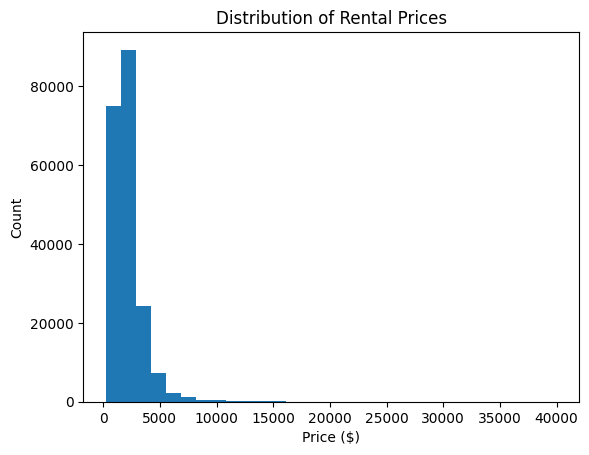

In [6]:
# Histogram: Price
plt.hist(df['price'], bins=30)
plt.title("Distribution of Rental Prices")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

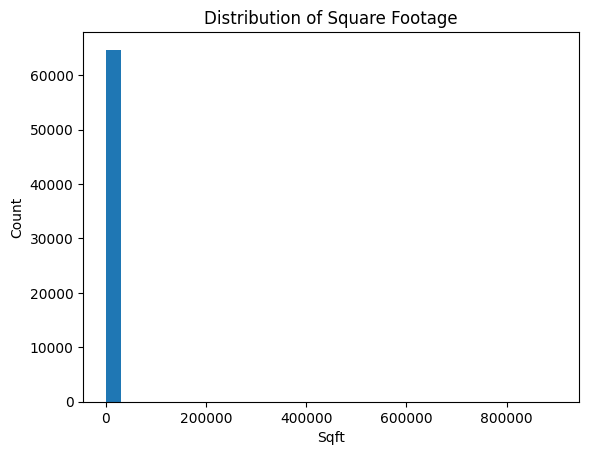

In [7]:
# Histogram: Square Footage
plt.hist(df['sqft'].dropna(), bins=30)
plt.title("Distribution of Square Footage")
plt.xlabel("Sqft")
plt.ylabel("Count")
plt.show()


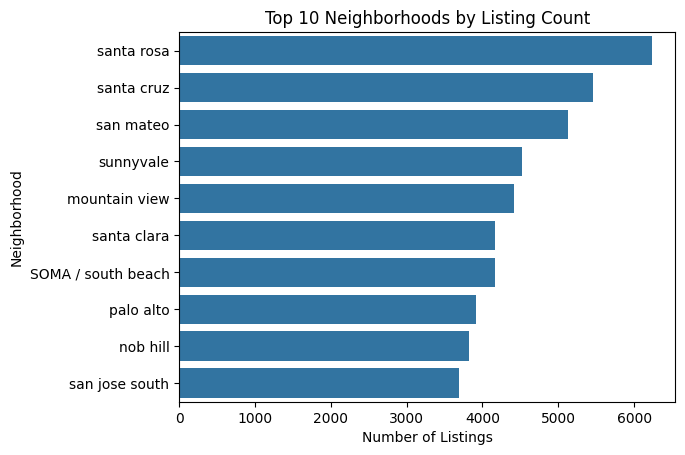

In [8]:
# Bar plot of top 10 neighborhoods by number of listings
top_nhoods = df['nhood'].value_counts().head(10)

sns.barplot(x=top_nhoods.values, y=top_nhoods.index)
plt.title("Top 10 Neighborhoods by Listing Count")
plt.xlabel("Number of Listings")
plt.ylabel("Neighborhood")
plt.show()

### üîß Do the following ‚Äì Part 3

1. Create two new visualizations using different variables than the ones already shown above.

>Suggestions:
- A **histogram** of the `baths` variable
- A **bar chart** showing the **average square footage by number of bathrooms**

> Be sure to label your axes and include a title for each chart.

### Reflection:

After creating each of the visuals, write 1‚Äì2 sentences explaining what you notice in each.


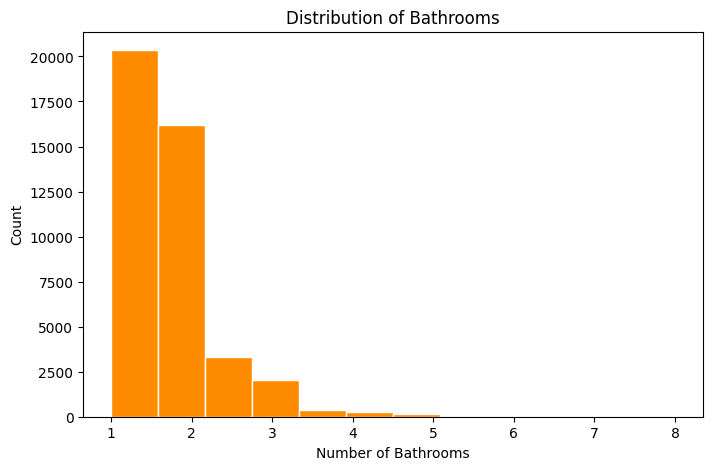

In [9]:
# Visual 1 🔧
plt.figure(figsize=(8, 5))
plt.hist(df['baths'].dropna(), bins=12, edgecolor='white', color='darkorange')
plt.title("Distribution of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Count")
plt.show()


### ✍️ Visual 1 Response: 🔧
1. The bathroom distribution is concentrated around 1 and 2 bathrooms, which suggests that most listings are apartments or smaller rental units. Listings with 3 or more bathrooms are much less common and represent larger or more specialized properties.


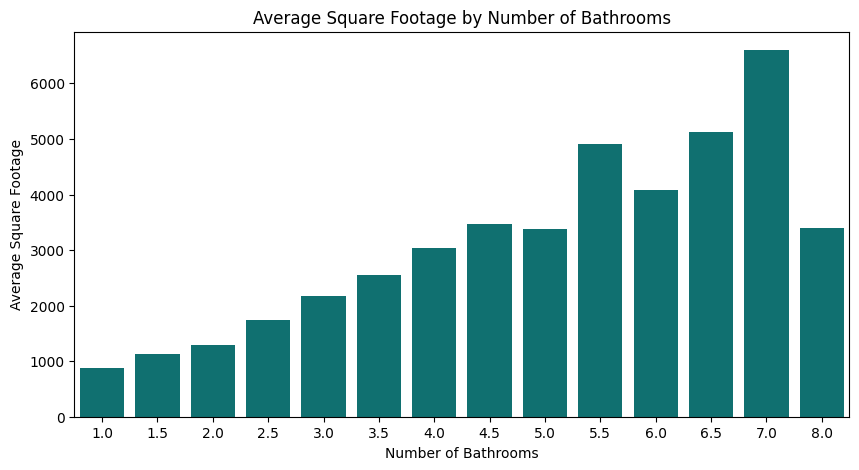

In [10]:
# Visual 2 🔧
avg_sqft_baths = df.groupby('baths')['sqft'].mean().dropna().sort_index()
plt.figure(figsize=(10, 5))
sns.barplot(x=avg_sqft_baths.index.astype(str), y=avg_sqft_baths.values, color='teal')
plt.title("Average Square Footage by Number of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Average Square Footage")
plt.xticks(rotation=0)
plt.show()


### ✍️ Visual 2 Response: 🔧
1. Average square footage generally increases as the number of bathrooms increases, which is expected because larger homes usually need more bathrooms. The pattern is not perfectly smooth, likely because some bathroom groups have fewer listings and because location and property type also affect size.


## 4. Bivariate Analysis

Explore relationships between two variables to understand how features like square footage or bedrooms influence price.


In [11]:
# Correlation matrix
corr_matrix = df[['price', 'beds', 'baths', 'sqft']].corr()
corr_matrix


,price,beds,baths,sqft
price,1.000000,0.450096,0.433553,0.074310
beds,0.450096,1.000000,0.651835,0.707235
baths,0.433553,0.651835,1.000000,0.645372
sqft,0.074310,0.707235,0.645372,1.000000


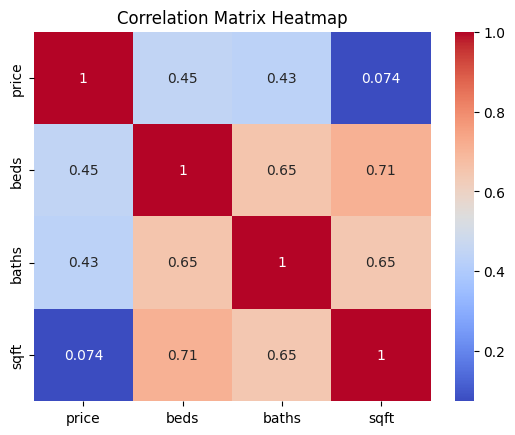

In [12]:
# Heatmap of correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix Heatmap")
plt.show()

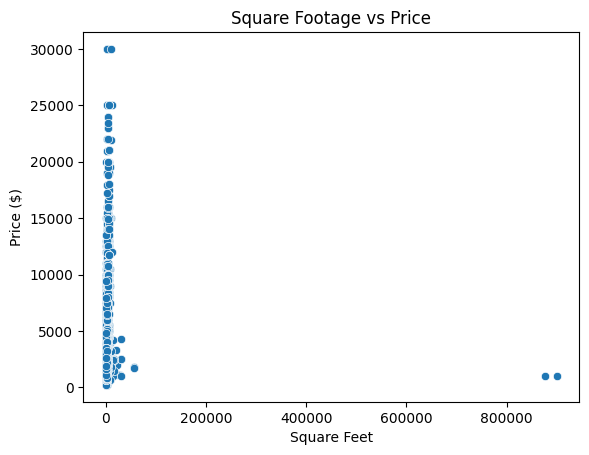

In [13]:
# Scatterplot: Square Footage vs Price
sns.scatterplot(x='sqft', y='price', data=df)
plt.title("Square Footage vs Price")
plt.xlabel("Square Feet")
plt.ylabel("Price ($)")
plt.show()

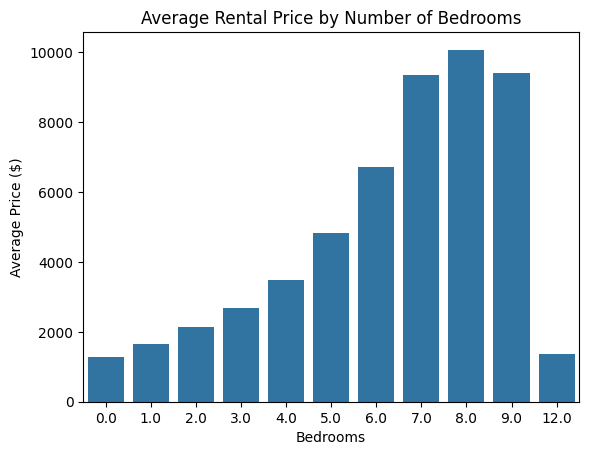

In [14]:
# Average price by number of bedrooms
avg_price_beds = df.groupby('beds')['price'].mean().sort_index()
sns.barplot(x=avg_price_beds.index, y=avg_price_beds.values)
plt.title("Average Rental Price by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price ($)")
plt.show()

### üîß Do the following ‚Äì Part 4

- 4.1 Create a scatterplot of `baths` vs `price`.  
- 4.2 Group by `year` and plot the average price over time.

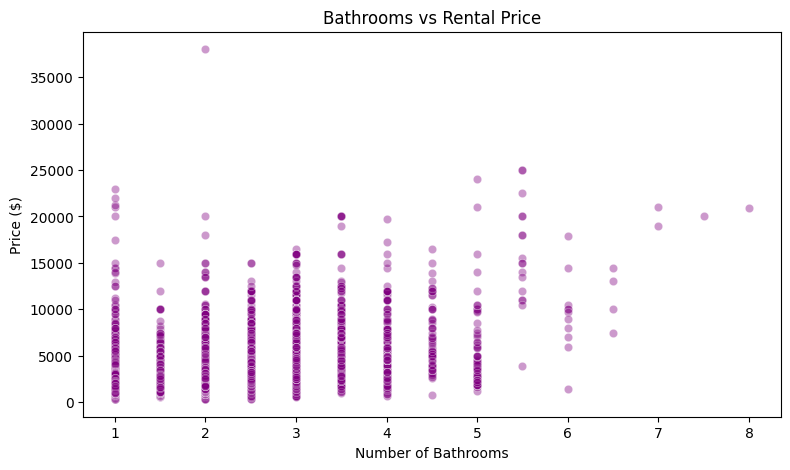

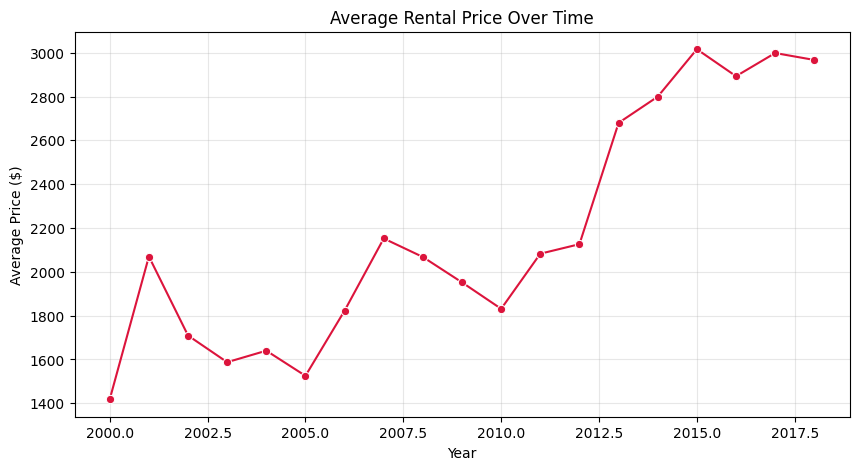

In [15]:
# Add code here 🔧
# 4.1 Scatterplot of baths vs price
plt.figure(figsize=(9, 5))
sns.scatterplot(x='baths', y='price', data=df, alpha=0.4, color='purple')
plt.title("Bathrooms vs Rental Price")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Price ($)")
plt.show()

# 4.2 Average price by year
avg_price_year = df.groupby('year')['price'].mean().sort_index()
plt.figure(figsize=(10, 5))
sns.lineplot(x=avg_price_year.index, y=avg_price_year.values, marker='o', color='crimson')
plt.title("Average Rental Price Over Time")
plt.xlabel("Year")
plt.ylabel("Average Price ($)")
plt.grid(True, alpha=0.3)
plt.show()


### Reflection:
4.1 What trends or outliers do you see?

### ✍️ Your Response: 🔧
**4.1** Bathrooms have a positive relationship with rental price (correlation about 0.43), so listings with more bathrooms tend to be more expensive. However, there is a lot of spread, and a few very high-price listings appear even at lower bathroom counts, suggesting that location, luxury features, or data issues may also be important.


## üîß  Part 5: Reflection

Answer the following questions in the markdown cell below (no more than a few sentences per question required)

- 5.1 Which variables are most strongly correlated with rental price?
- 5.2 Are there patterns in how size (sqft) or number of bedrooms affects price?
- 5.3 Which neighborhoods or years show the highest prices?
- 5.4 What other visualizations or groupings might improve this analysis?

Use this section to summarize insights from both Labs 4 and 5.

### ✍️ Your Response: 🔧
**5.1** The strongest correlation with rental price in this numeric set is beds (about 0.45). The other relationships are also positive but weaker: baths is about 0.43, beds is about 0.45, and sqft is about 0.07.

**5.2** Size and bedroom count both show positive patterns with price, meaning larger listings and listings with more bedrooms generally rent for more. The relationship is noisy because price is also affected by neighborhood, property type, amenities, and outliers.

**5.3** The highest average neighborhood price in this dataset is inverness at about 5,310 dollars. By year, the highest average price appears in 2015, at about 3,016 dollars.

**5.4** This analysis could be improved with neighborhood-level boxplots, log-scaled price charts, maps using latitude/longitude, and separate trends by neighborhood or room-in-apartment status. Those views would help separate true market patterns from extreme outliers.


## Export Your Notebook to Submit in Canvas
- Use the instructions from Lab 1

In [16]:
# Export command used after completing the notebook:
# jupyter nbconvert --to html "lab_04_eda.ipynb"
